In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error as mae, root_mean_squared_error as rmse, mean_absolute_percentage_error as mape, r2_score as r2

from sklearn import linear_model
import time

from catboost import CatBoostRegressor

import matplotlib.pyplot as plt



In [ ]:
cpu = pd.read_csv("../datasets/raw/CPU_benchmark_v4.csv")

In [ ]:
cpu.head()

In [ ]:
cpu.shape

In [ ]:
cpu.info()

In [ ]:
cpu.isna().sum()

In [ ]:
cpu = cpu.drop(['cpuName','price','cpuValue','threadValue','powerPerf','socket'],axis=1)

In [ ]:
cpu.info()

In [ ]:
cpu['TDP'] = cpu['TDP'].fillna(cpu['TDP'].median())

In [ ]:
cpu.info()

In [ ]:
#Cleaning and Convert category into individual Boolean using get_dummies
cpu['category'] = cpu['category'].str.replace(' ','')
seperate_categories = cpu['category'].str.get_dummies(sep=',')
cpu = pd.concat([cpu,seperate_categories],axis=1)

cpu = cpu.drop('category',axis=1)

In [ ]:
seperate_categories.head()

In [ ]:
cpu.head()

In [ ]:
cpu.info()

In [ ]:
cpu.to_csv('../datasets/processed/cpu_cleaned.csv',index=False)

In [2]:
cpu_model = pd.read_csv('../datasets/processed/cpu_cleaned.csv')

In [3]:
cpu_model[['threadMark', 'TDP', 'cores','testDate', 'cpuMark']].describe()

,threadMark,TDP,cores,testDate,cpuMark
count,3825.000000,3825.000000,3825.000000,3825.000000,3825.000000
mean,1391.107451,60.696536,5.052288,2015.027974,5992.305882
std,815.667528,43.235515,6.185833,4.597616,9617.551479
min,75.000000,2.000000,1.000000,2007.000000,77.000000
25%,729.000000,35.000000,2.000000,2011.000000,943.000000
50%,1274.000000,53.000000,4.000000,2015.000000,2331.000000
75%,1961.000000,77.000000,6.000000,2020.000000,6643.000000
max,4317.000000,300.000000,80.000000,2022.000000,108822.000000


In [4]:
X = cpu_model.drop('cpuMark', axis=1)
y = cpu_model['cpuMark']

In [5]:
X.head()

,threadMark,TDP,cores,testDate,Desktop,Laptop,Mobile/Embedded,Server,Unknown
0,3330,280.0,64,2022,1,0,0,0,0
1,2635,280.0,64,2021,0,0,0,1,0
2,2387,53.0,64,2021,0,0,0,1,0
3,2727,225.0,64,2021,0,0,0,1,0
4,2626,280.0,64,2020,1,0,0,0,0


In [6]:
y.head()

0    108822
1     88338
2     86006
3     85861
4     83971
Name: cpuMark, dtype: int64

In [7]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=1)

In [8]:
time_start = time.perf_counter()
reg_linear = linear_model.LinearRegression()
reg_linear.fit(X_train,y_train)
end_time = time.perf_counter()

training_time = end_time - time_start

predict_linear = reg_linear.predict(X_test)

In [9]:
print("Test set shape: ",y_test.shape)
print("Prediction Shape: ",predict_linear.shape)

Test set shape:  (1148,)
Prediction Shape:  (1148,)


In [10]:
mae_reg_linear = mae(y_test, predict_linear)
rmse_reg_linear = rmse(y_test,predict_linear)
mape_reg_linear = mape(y_test,predict_linear)
r2_reg_linear = r2(y_test,predict_linear)
duration_reg_linear = end_time - time_start

print('Linear Regression MAE: {}'.format(mae_reg_linear))
print('Linear Regression RMSE: {}'.format(rmse_reg_linear))
print('Linear Regression MAPE: {}'.format(mape_reg_linear))
print('Linear Regression R2 Score: {}'.format(r2_reg_linear))
print('Training Duration: {:.6f} Seconds'.format(duration_reg_linear))

Linear Regression MAE: 2286.953953653316
Linear Regression RMSE: 3426.075511034746
Linear Regression MAPE: 1.9285600534835128
Linear Regression R2 Score: 0.877835897856433
Training Duration: 0.011451 Seconds


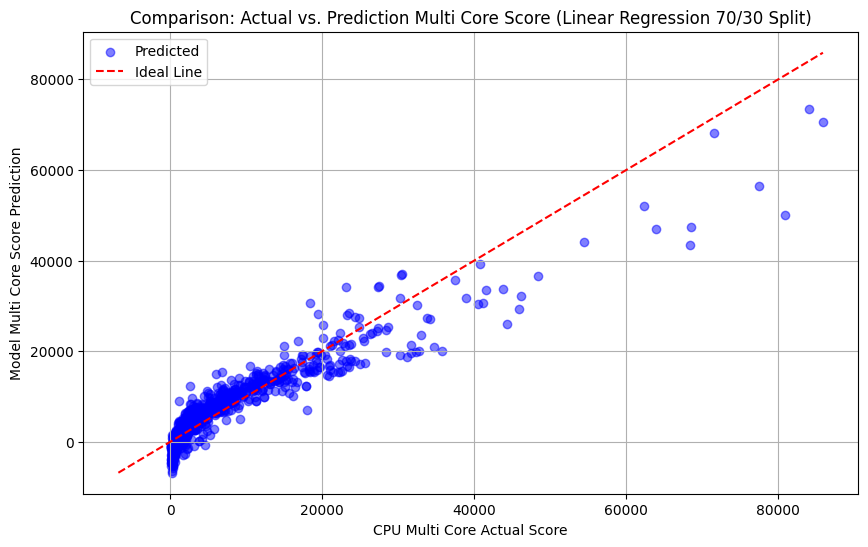

In [11]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, predict_linear, alpha=0.5, color='blue', label='Predicted')
min_val = min(y_test.min(), predict_linear.min())
max_val = max(y_test.max(), predict_linear.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Ideal Line')
plt.title('Comparison: Actual vs. Prediction Multi Core Score (Linear Regression 70/30 Split)')
plt.xlabel('CPU Multi Core Actual Score')
plt.ylabel('Model Multi Core Score Prediction')
plt.legend()
plt.grid(True)


In [12]:
#CatBoost Regression Model Training

time_start = time.perf_counter()
reg_catboost = CatBoostRegressor()
reg_catboost.fit(X_train,y_train)
end_time = time.perf_counter()

predict_catboost = reg_catboost.predict(X_test)

Learning rate set to 0.047835
0:	learn: 9184.2397965	total: 78ms	remaining: 1m 17s
1:	learn: 8864.1372925	total: 79.1ms	remaining: 39.5s
2:	learn: 8568.6969462	total: 80ms	remaining: 26.6s
3:	learn: 8273.3707052	total: 80.9ms	remaining: 20.1s
4:	learn: 7987.1089368	total: 81.9ms	remaining: 16.3s
5:	learn: 7710.6899452	total: 82.8ms	remaining: 13.7s
6:	learn: 7444.8193972	total: 83.8ms	remaining: 11.9s
7:	learn: 7191.6744223	total: 84.7ms	remaining: 10.5s
8:	learn: 6959.0239825	total: 85.6ms	remaining: 9.42s
9:	learn: 6740.3237325	total: 86.5ms	remaining: 8.56s
10:	learn: 6530.6916196	total: 87.4ms	remaining: 7.86s
11:	learn: 6323.6261663	total: 88.3ms	remaining: 7.27s
12:	learn: 6108.9969127	total: 89.2ms	remaining: 6.77s
13:	learn: 5914.9593368	total: 90.1ms	remaining: 6.34s
14:	learn: 5728.8866547	total: 91ms	remaining: 5.97s
15:	learn: 5569.2335406	total: 91.9ms	remaining: 5.65s
16:	learn: 5408.8500290	total: 92.8ms	remaining: 5.37s
17:	learn: 5239.2168358	total: 93.7ms	remaining: 5

In [13]:
#Catboost Regression Evaluation Metrics
from sklearn.metrics import mean_absolute_error as mae, root_mean_squared_error as rmse, mean_absolute_percentage_error as mape, r2_score as r2

mae_catboost = mae(y_test, predict_catboost)
rmse_catboost = rmse(y_test,predict_catboost)
mape_catboost = mape(y_test,predict_catboost)
r2_catboost = r2(y_test,predict_catboost)
duration_catboost = end_time - time_start

print('CatBoost Regression MAE: {}'.format(mae_catboost))
print('CatBoost Regression RMSE: {}'.format(rmse_catboost))
print('CatBoost Regression MAPE: {}'.format(mape_catboost))
print('CatBoost Regression R2: {}'.format(r2_catboost))
print('Training Duration: {:.6f} Seconds'.format(duration_catboost))

CatBoost Regression MAE: 687.540986202594
CatBoost Regression RMSE: 1505.3857170634199
CatBoost Regression MAPE: 0.17019254858134997
CatBoost Regression R2: 0.9764144869084221
Training Duration: 1.186907 Seconds


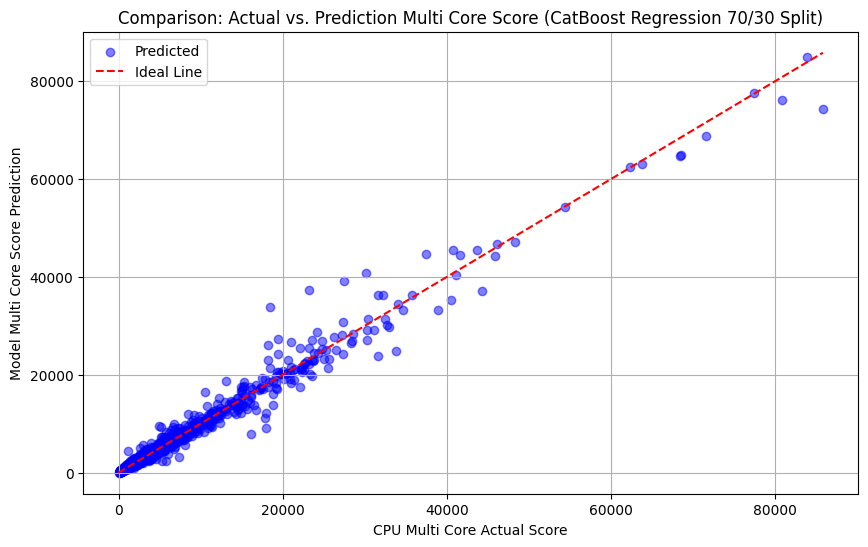

In [14]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, predict_catboost, alpha=0.5, color='blue', label='Predicted')
min_val = min(y_test.min(), predict_catboost.min())
max_val = max(y_test.max(), predict_catboost.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Ideal Line')
plt.title('Comparison: Actual vs. Prediction Multi Core Score (CatBoost Regression 70/30 Split)')
plt.xlabel('CPU Multi Core Actual Score')
plt.ylabel('Model Multi Core Score Prediction')
plt.legend()
plt.grid(True)

plt.show()

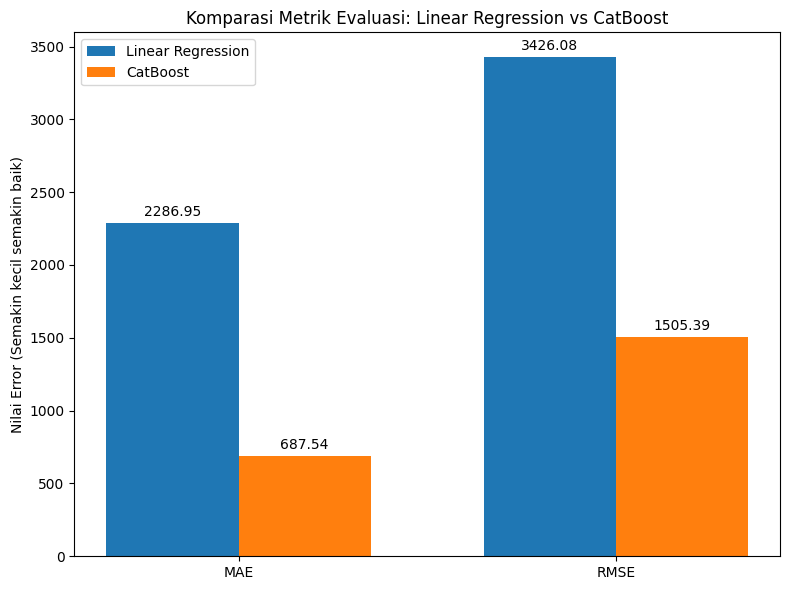

In [15]:
metrics = ['MAE', 'RMSE']
linear_scores = [mae_reg_linear, rmse_reg_linear]
catboost_scores = [mae_catboost, rmse_catboost]


x = np.arange(len(metrics))
width = 0.35  
fig, ax = plt.subplots(figsize=(8, 6))

rects1 = ax.bar(x - width/2, linear_scores, width, label='Linear Regression', color='#1f77b4')
rects2 = ax.bar(x + width/2, catboost_scores, width, label='CatBoost', color='#ff7f0e')

ax.set_ylabel('Nilai Error (Semakin kecil semakin baik)')
ax.set_title('Komparasi Metrik Evaluasi: Linear Regression vs CatBoost')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()

ax.bar_label(rects1, padding=3, fmt='%.2f')
ax.bar_label(rects2, padding=3, fmt='%.2f')

fig.tight_layout()
plt.show()

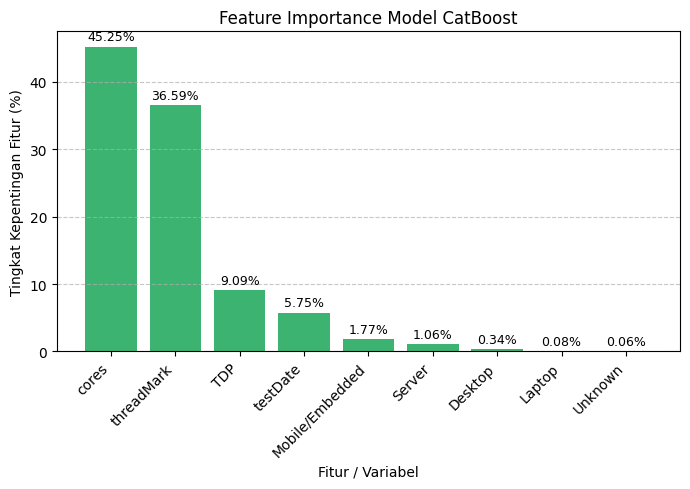

In [16]:
feature_importance = reg_catboost.get_feature_importance()

feature_names = X_train.columns

fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importance})
fi_df = fi_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(7, 5))
plt.bar(fi_df['Feature'], fi_df['Importance'], color='mediumseagreen')

plt.xlabel('Fitur / Variabel')
plt.ylabel('Tingkat Kepentingan Fitur (%)')
plt.title('Feature Importance Model CatBoost')
plt.grid(axis='y', linestyle='--', alpha=0.7) 

plt.xticks(rotation=45, ha='right')

for index, value in enumerate(fi_df['Importance']):
    plt.text(index, value + 0.5, f'{value:.2f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

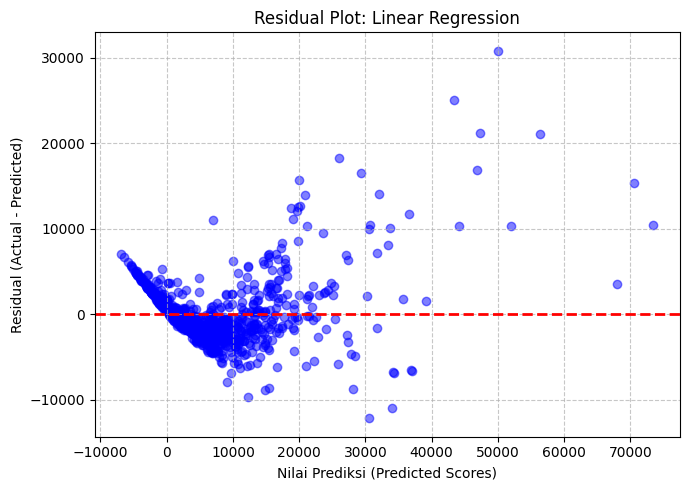

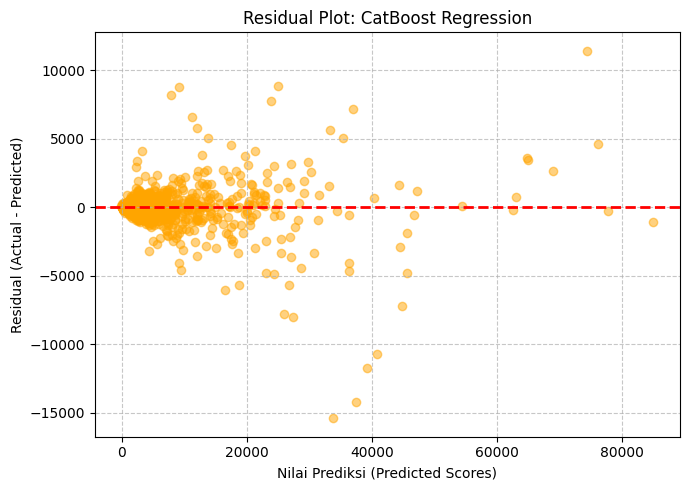

In [17]:
residual_linear = y_test - predict_linear
residual_catboost = y_test - predict_catboost

plt.figure(figsize=(7, 5)) 
plt.scatter(predict_linear, residual_linear, alpha=0.5, color='blue')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.title('Residual Plot: Linear Regression')
plt.xlabel('Nilai Prediksi (Predicted Scores)')
plt.ylabel('Residual (Actual - Predicted)')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show() 

plt.figure(figsize=(7, 5)) 
plt.scatter(predict_catboost, residual_catboost, alpha=0.5, color='orange')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.title('Residual Plot: CatBoost Regression')
plt.xlabel('Nilai Prediksi (Predicted Scores)')
plt.ylabel('Residual (Actual - Predicted)')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## 80:20 Dataset Tes

In [18]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=1)

In [19]:
time_start = time.perf_counter()
reg_linear = linear_model.LinearRegression()
reg_linear.fit(X_train,y_train)
end_time = time.perf_counter()

training_time = end_time - time_start

predict_linear = reg_linear.predict(X_test)

In [20]:
print("Test set shape: ",y_test.shape)
print("Prediction Shape: ",predict_linear.shape)

Test set shape:  (765,)
Prediction Shape:  (765,)


In [21]:
#8020
mae_reg_linear = mae(y_test, predict_linear)
rmse_reg_linear = rmse(y_test,predict_linear)
mape_reg_linear = mape(y_test,predict_linear)
r2_reg_linear = r2(y_test,predict_linear)
duration_reg_linear = end_time - time_start

print('Linear Regression MAE: {}'.format(mae_reg_linear))
print('Linear Regression RMSE: {}'.format(rmse_reg_linear))
print('Linear Regression MAPE: {}'.format(mape_reg_linear))
print('Linear Regression R2 Score: {}'.format(r2_reg_linear))
print('Training Duration: {:.6f} Seconds'.format(duration_reg_linear))

Linear Regression MAE: 2270.262209761036
Linear Regression RMSE: 3553.5167631603167
Linear Regression MAPE: 1.9447455188715492
Linear Regression R2 Score: 0.886310810247367
Training Duration: 0.001684 Seconds


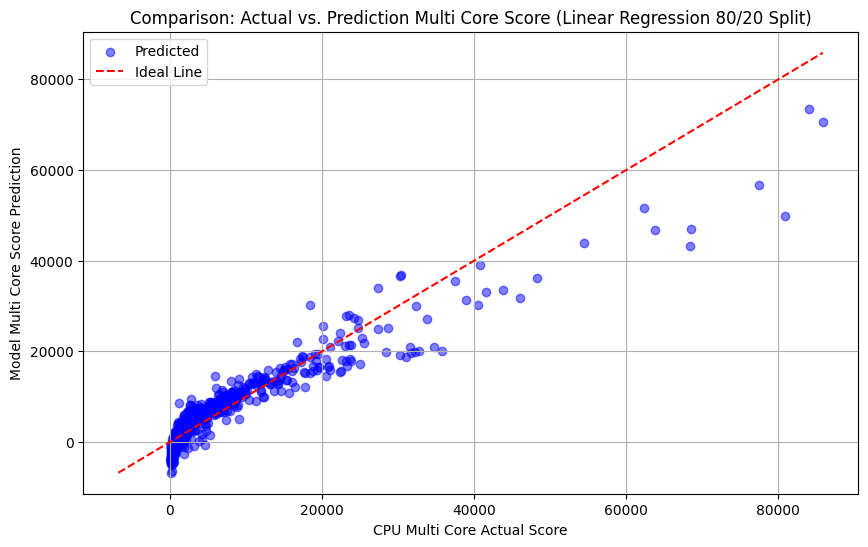

In [23]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, predict_linear, alpha=0.5, color='blue', label='Predicted')
min_val = min(y_test.min(), predict_linear.min())
max_val = max(y_test.max(), predict_linear.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Ideal Line')
plt.title('Comparison: Actual vs. Prediction Multi Core Score (Linear Regression 80/20 Split)')
plt.xlabel('CPU Multi Core Actual Score')
plt.ylabel('Model Multi Core Score Prediction')
plt.legend()
plt.grid(True)


In [24]:
#CatBoost Regression Model Training

time_start = time.perf_counter()
reg_catboost = CatBoostRegressor()
reg_catboost.fit(X_train,y_train)
end_time = time.perf_counter()

predict_catboost = reg_catboost.predict(X_test)

Learning rate set to 0.048857
0:	learn: 9018.2436726	total: 1.09ms	remaining: 1.09s
1:	learn: 8687.6875515	total: 2.09ms	remaining: 1.04s
2:	learn: 8373.9766944	total: 3.17ms	remaining: 1.05s
3:	learn: 8081.6059424	total: 4.3ms	remaining: 1.07s
4:	learn: 7801.9449530	total: 5.42ms	remaining: 1.08s
5:	learn: 7526.2463797	total: 6.48ms	remaining: 1.07s
6:	learn: 7268.4786403	total: 7.45ms	remaining: 1.06s
7:	learn: 7016.4391953	total: 8.42ms	remaining: 1.04s
8:	learn: 6782.0403911	total: 9.4ms	remaining: 1.03s
9:	learn: 6561.4244390	total: 10.3ms	remaining: 1.02s
10:	learn: 6350.0856458	total: 11.3ms	remaining: 1.01s
11:	learn: 6137.3524222	total: 12.2ms	remaining: 1s
12:	learn: 5940.9933225	total: 13.1ms	remaining: 994ms
13:	learn: 5766.8870984	total: 14ms	remaining: 986ms
14:	learn: 5592.7481224	total: 14.9ms	remaining: 981ms
15:	learn: 5428.3451375	total: 15.8ms	remaining: 974ms
16:	learn: 5274.0717907	total: 16.7ms	remaining: 968ms
17:	learn: 5128.0626608	total: 17.7ms	remaining: 966

In [25]:
#Catboost Regression Evaluation Metrics 8020
from sklearn.metrics import mean_absolute_error as mae, root_mean_squared_error as rmse, mean_absolute_percentage_error as mape, r2_score as r2

mae_catboost = mae(y_test, predict_catboost)
rmse_catboost = rmse(y_test,predict_catboost)
mape_catboost = mape(y_test,predict_catboost)
r2_catboost = r2(y_test,predict_catboost)
duration_catboost = end_time - time_start

print('CatBoost Regression MAE: {}'.format(mae_catboost))
print('CatBoost Regression RMSE: {}'.format(rmse_catboost))
print('CatBoost Regression MAPE: {}'.format(mape_catboost))
print('CatBoost Regression R2: {}'.format(r2_catboost))
print('Training Duration: {:.6f} Seconds'.format(duration_catboost))

CatBoost Regression MAE: 615.4287144774534
CatBoost Regression RMSE: 1313.9762361616208
CatBoost Regression MAPE: 0.15204192348349385
CatBoost Regression R2: 0.9844554749844521
Training Duration: 1.030635 Seconds


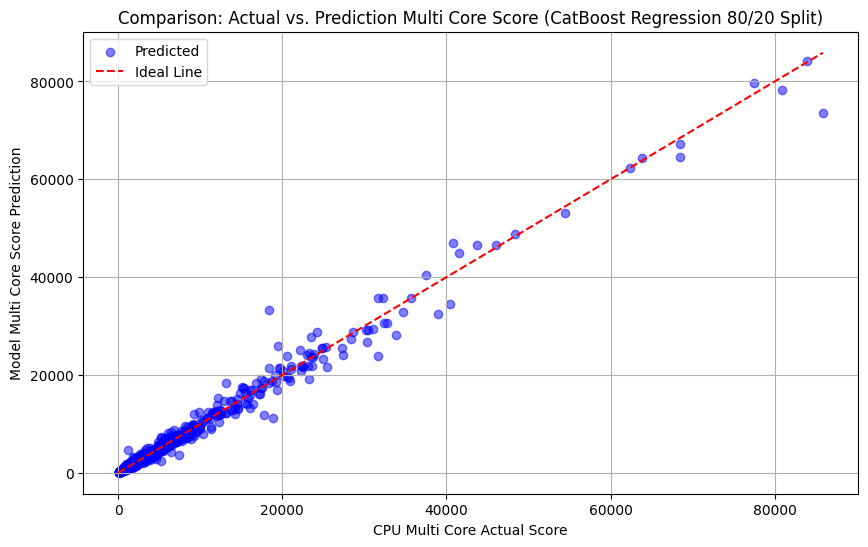

In [26]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, predict_catboost, alpha=0.5, color='blue', label='Predicted')
min_val = min(y_test.min(), predict_catboost.min())
max_val = max(y_test.max(), predict_catboost.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Ideal Line')
plt.title('Comparison: Actual vs. Prediction Multi Core Score (CatBoost Regression 80/20 Split)')
plt.xlabel('CPU Multi Core Actual Score')
plt.ylabel('Model Multi Core Score Prediction')
plt.legend()
plt.grid(True)

plt.show()

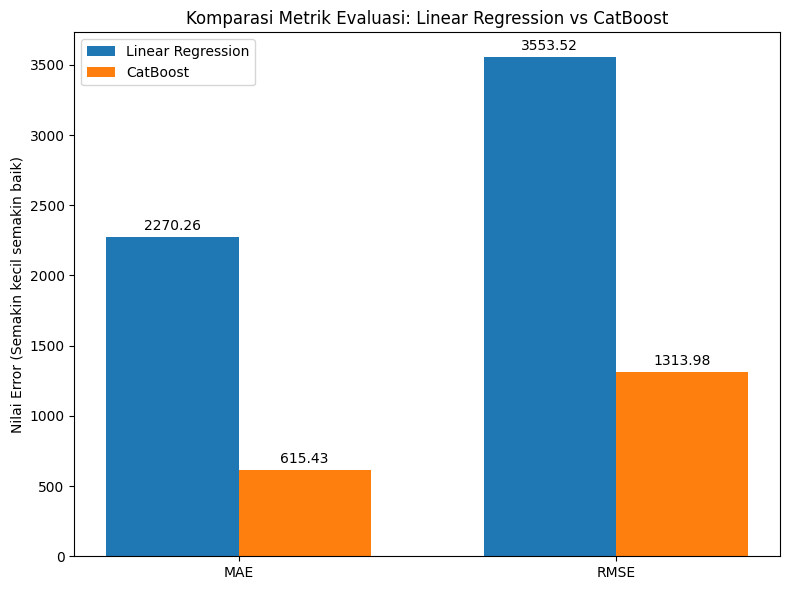

In [27]:
#8020
metrics = ['MAE', 'RMSE']
linear_scores = [mae_reg_linear, rmse_reg_linear]
catboost_scores = [mae_catboost, rmse_catboost]


x = np.arange(len(metrics))
width = 0.35  
fig, ax = plt.subplots(figsize=(8, 6))

rects1 = ax.bar(x - width/2, linear_scores, width, label='Linear Regression', color='#1f77b4')
rects2 = ax.bar(x + width/2, catboost_scores, width, label='CatBoost', color='#ff7f0e')

ax.set_ylabel('Nilai Error (Semakin kecil semakin baik)')
ax.set_title('Komparasi Metrik Evaluasi: Linear Regression vs CatBoost')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()

ax.bar_label(rects1, padding=3, fmt='%.2f')
ax.bar_label(rects2, padding=3, fmt='%.2f')

fig.tight_layout()
plt.show()

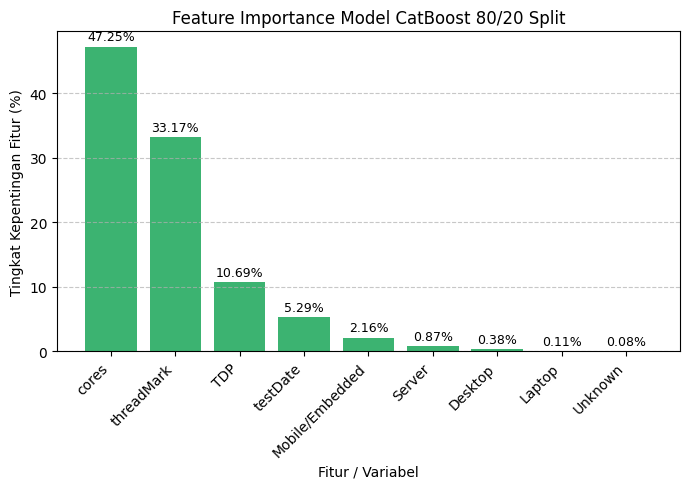

In [31]:
#8020
feature_importance = reg_catboost.get_feature_importance()

feature_names = X_train.columns

fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importance})
fi_df = fi_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(7, 5))
plt.bar(fi_df['Feature'], fi_df['Importance'], color='mediumseagreen')

plt.xlabel('Fitur / Variabel')
plt.ylabel('Tingkat Kepentingan Fitur (%)')
plt.title('Feature Importance Model CatBoost 80/20 Split')
plt.grid(axis='y', linestyle='--', alpha=0.7) 

plt.xticks(rotation=45, ha='right')

for index, value in enumerate(fi_df['Importance']):
    plt.text(index, value + 0.5, f'{value:.2f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

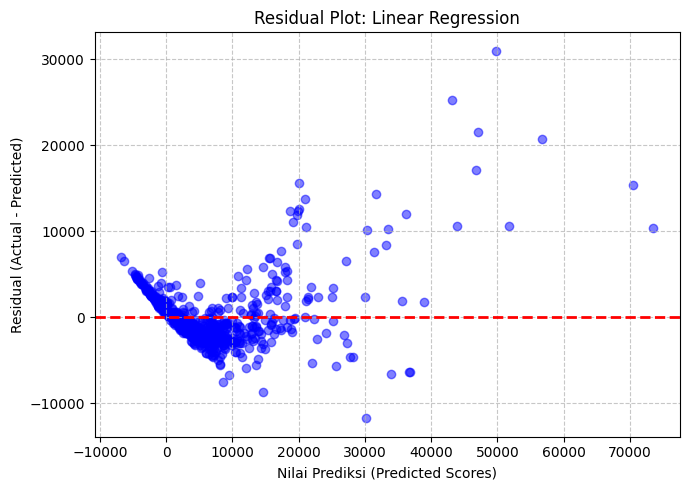

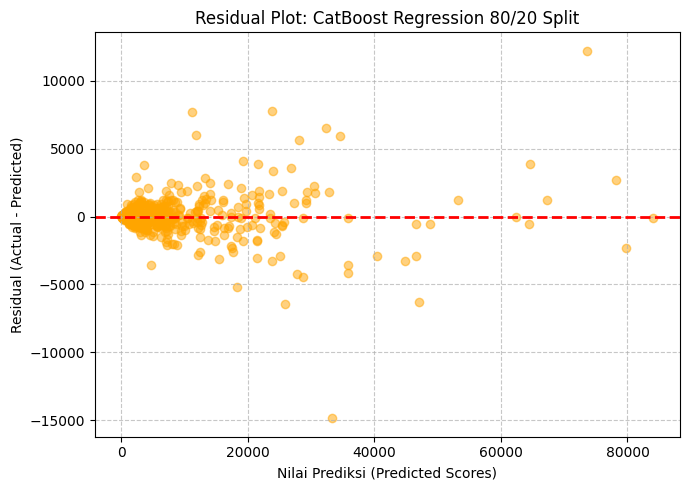

In [30]:
#8020
residual_linear = y_test - predict_linear
residual_catboost = y_test - predict_catboost

plt.figure(figsize=(7, 5)) 
plt.scatter(predict_linear, residual_linear, alpha=0.5, color='blue')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.title('Residual Plot: Linear Regression')
plt.xlabel('Nilai Prediksi (Predicted Scores)')
plt.ylabel('Residual (Actual - Predicted)')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show() 

plt.figure(figsize=(7, 5)) 
plt.scatter(predict_catboost, residual_catboost, alpha=0.5, color='orange')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.title('Residual Plot: CatBoost Regression 80/20 Split')
plt.xlabel('Nilai Prediksi (Predicted Scores)')
plt.ylabel('Residual (Actual - Predicted)')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()